In [20]:
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files

In [21]:
!pip install roboflow

In [22]:
# Mounting google drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [23]:
import os
dataset_path = "/content/drive/MyDrive/biscuit-dataset"
os.listdir(dataset_path)

['Screenshot 2025-04-10 103328_png.rf.yHJzmaG620tcIUtXEEyx.png',
 '20250409_224602(0)_jpg.rf.f3epPkD8TJZRSlFxcN9h.jpg',
 '20250409_224810_jpg.rf.5m0ZtquHRez3oYwwmS30.jpg',
 '20250409_224800_jpg.rf.3OGTaI6noeDZ4GP929Wz.jpg',
 '20250409_224610_jpg.rf.amRPy2tl4Qm8Lxw6c1Pr.jpg',
 '20250410_111347_jpg.rf.5PzIZschJ3Wh81yyu081.jpg',
 'Screenshot 2025-03-19 231358_png.rf.tnpnFpkrx7vSgm83KRip.png',
 '20250410_093005_jpg.rf.sN4RXYiMyJKEvWHvJu7b.jpg',
 '20250410_092926_jpg.rf.dqmNa5AztIKqzchIGI5d.jpg',
 'Screenshot 2025-03-19 231059_png.rf.a7Gm06Ml1AgwTsmTdEdx.png',
 'Screenshot 2025-04-10 104046_png.rf.dm277oyNkFSXr1jl76DO.png',
 '20250410_092906_jpg.rf.2Rd2wx5mfzxDuDir2RuG.jpg',
 '20250409_224616_jpg.rf.xv2dSIVEKGb4nEWLwoAH.jpg',
 '20250410_092904(0)_jpg.rf.3LUhvdBuYqVVvN1n8gbR.jpg',
 '20250410_111334(0)_jpg.rf.a4ZFAM5ofEfT4ArxwB8W.jpg',
 '20250410_111233_jpg.rf.5DNHtPUzs1vSVbdAdUPM.jpg',
 '20250409_224606_jpg.rf.49SG5w3EAl414TpxMSy4.jpg',
 '20250409_224628_jpg.rf.48TH8jEf0EXg4Fm1vasu.jpg',
 'S

In [24]:
import cv2

In [25]:
# loading a sample of biscuit image
image_path = dataset_path + "/Screenshot 2025-04-10 103826_png.rf.4ht7Om4UC0baJ273WaXd.png"

image = cv2.imread(image_path)

In [26]:
print(os.listdir(dataset_path))

['Screenshot 2025-04-10 103328_png.rf.yHJzmaG620tcIUtXEEyx.png', '20250409_224602(0)_jpg.rf.f3epPkD8TJZRSlFxcN9h.jpg', '20250409_224810_jpg.rf.5m0ZtquHRez3oYwwmS30.jpg', '20250409_224800_jpg.rf.3OGTaI6noeDZ4GP929Wz.jpg', '20250409_224610_jpg.rf.amRPy2tl4Qm8Lxw6c1Pr.jpg', '20250410_111347_jpg.rf.5PzIZschJ3Wh81yyu081.jpg', 'Screenshot 2025-03-19 231358_png.rf.tnpnFpkrx7vSgm83KRip.png', '20250410_093005_jpg.rf.sN4RXYiMyJKEvWHvJu7b.jpg', '20250410_092926_jpg.rf.dqmNa5AztIKqzchIGI5d.jpg', 'Screenshot 2025-03-19 231059_png.rf.a7Gm06Ml1AgwTsmTdEdx.png', 'Screenshot 2025-04-10 104046_png.rf.dm277oyNkFSXr1jl76DO.png', '20250410_092906_jpg.rf.2Rd2wx5mfzxDuDir2RuG.jpg', '20250409_224616_jpg.rf.xv2dSIVEKGb4nEWLwoAH.jpg', '20250410_092904(0)_jpg.rf.3LUhvdBuYqVVvN1n8gbR.jpg', '20250410_111334(0)_jpg.rf.a4ZFAM5ofEfT4ArxwB8W.jpg', '20250410_111233_jpg.rf.5DNHtPUzs1vSVbdAdUPM.jpg', '20250409_224606_jpg.rf.49SG5w3EAl414TpxMSy4.jpg', '20250409_224628_jpg.rf.48TH8jEf0EXg4Fm1vasu.jpg', 'Screenshot 2025-04-

(np.float64(-0.5), np.float64(639.5), np.float64(419.5), np.float64(-0.5))

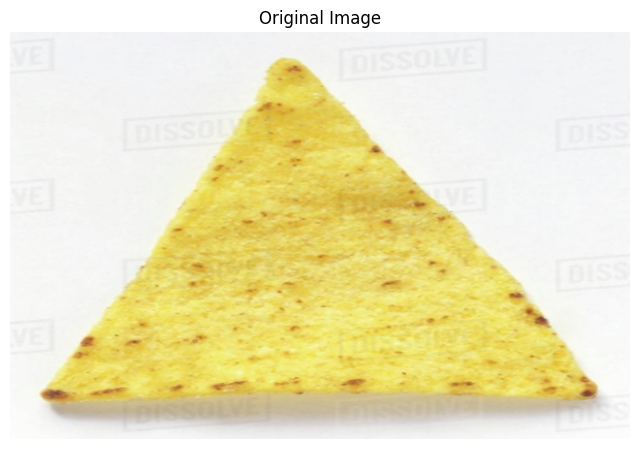

In [27]:
# converting BGR to RGB
import matplotlib.pyplot as plt
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(8,8))
plt.imshow(image_rgb)
plt.title("Original Image")
plt.axis("off")

(np.float64(-0.5), np.float64(639.5), np.float64(419.5), np.float64(-0.5))

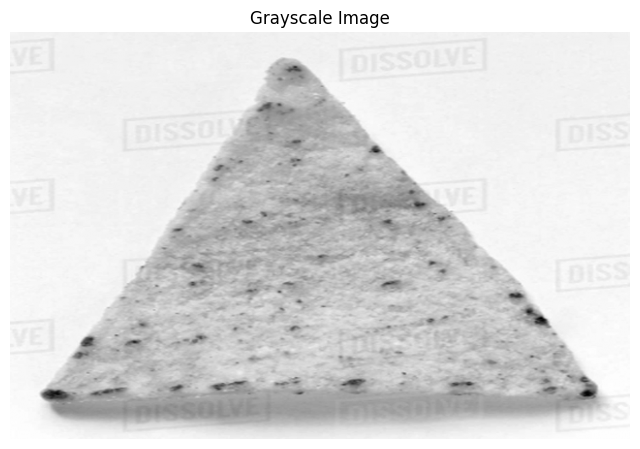

In [28]:
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

plt.figure(figsize=(8,8))
plt.imshow(gray, cmap='gray')
plt.title("Grayscale Image")
plt.axis("off")

# simplifies processing for:
#     thresholding
#     contour detection
#     segmentation.

(np.float64(-0.5), np.float64(639.5), np.float64(419.5), np.float64(-0.5))

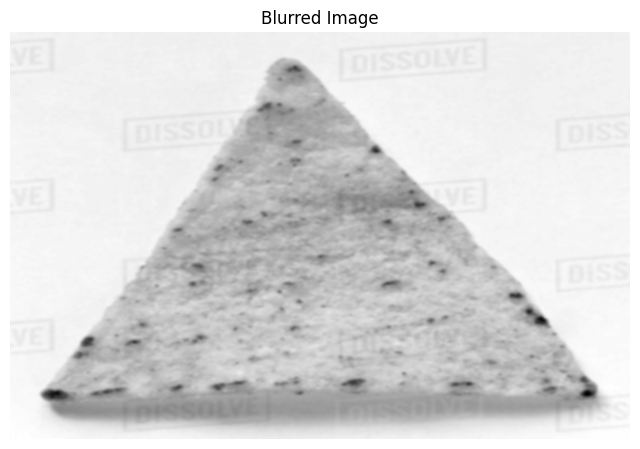

In [29]:
# Apply Gaussian blur to reduce noise before thresholding
blur = cv2.GaussianBlur(gray, (5,5), 0)

plt.figure(figsize=(8,8))
plt.imshow(blur, cmap='gray')
plt.title("Blurred Image")
plt.axis("off")

(np.float64(-0.5), np.float64(639.5), np.float64(419.5), np.float64(-0.5))

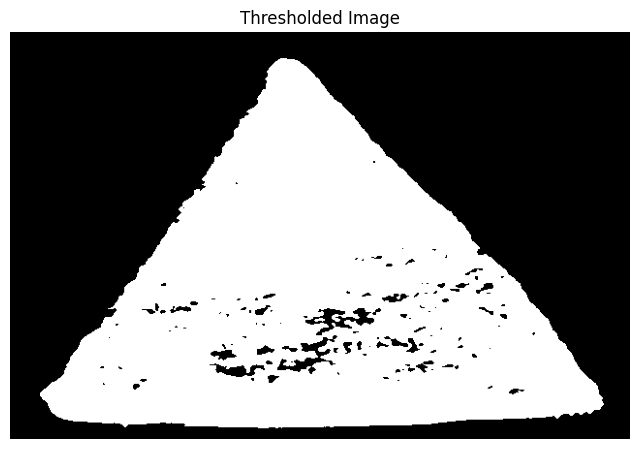

In [30]:
# Thresholding
_, thresh = cv2.threshold(
    blur,
    0,
    255,
    cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU
)

plt.figure(figsize=(8,8))
plt.imshow(thresh, cmap='gray')
plt.title("Thresholded Image")
plt.axis("off")

In [31]:
# contour detection
contours, _ = cv2.findContours(
    thresh,
    cv2.RETR_EXTERNAL,
    cv2.CHAIN_APPROX_SIMPLE
)

print("Total contours detected:", len(contours))

Total contours detected: 1


(np.float64(-0.5), np.float64(639.5), np.float64(419.5), np.float64(-0.5))

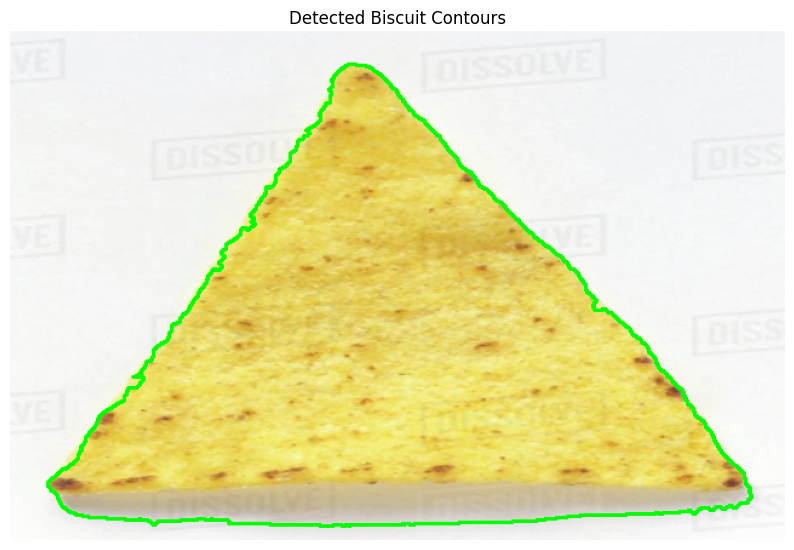

In [32]:
# Bounding box
output = image_rgb.copy()

for cnt in contours:

    area = cv2.contourArea(cnt)

    # Ignore very tiny contours/noise
    if area > 1000:

        cv2.drawContours(
            output,
            [cnt],
            -1,
            (0,255,0),
            2
        )

plt.figure(figsize=(10,10))
plt.imshow(output)
plt.title("Detected Biscuit Contours")
plt.axis("off")

Width: 582px | Height: 382px | Approx Diameter: 582px


(np.float64(-0.5), np.float64(639.5), np.float64(419.5), np.float64(-0.5))

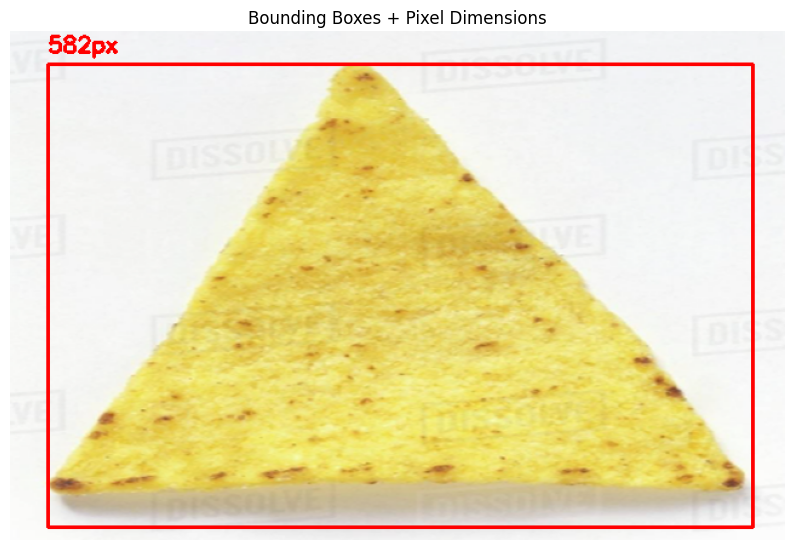

In [33]:
output_boxes = image_rgb.copy()

for cnt in contours:

    area = cv2.contourArea(cnt)

    # Ignore tiny noise
    if area > 1000:

        x, y, w, h = cv2.boundingRect(cnt)

        # Draw rectangle
        cv2.rectangle(
            output_boxes,
            (x, y),
            (x + w, y + h),
            (255, 0, 0),
            2
        )

        # Approx diameter
        diameter_pixels = max(w, h)

        # Put text
        cv2.putText(
            output_boxes,
            f"{diameter_pixels}px",
            (x, y - 10),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.6,
            (255, 0, 0),
            2
        )

        print(f"Width: {w}px | Height: {h}px | Approx Diameter: {diameter_pixels}px")

plt.figure(figsize=(10,10))
plt.imshow(output_boxes)
plt.title("Bounding Boxes + Pixel Dimensions")
plt.axis("off")

Estimated Diameter: 592px


(np.float64(-0.5), np.float64(639.5), np.float64(419.5), np.float64(-0.5))

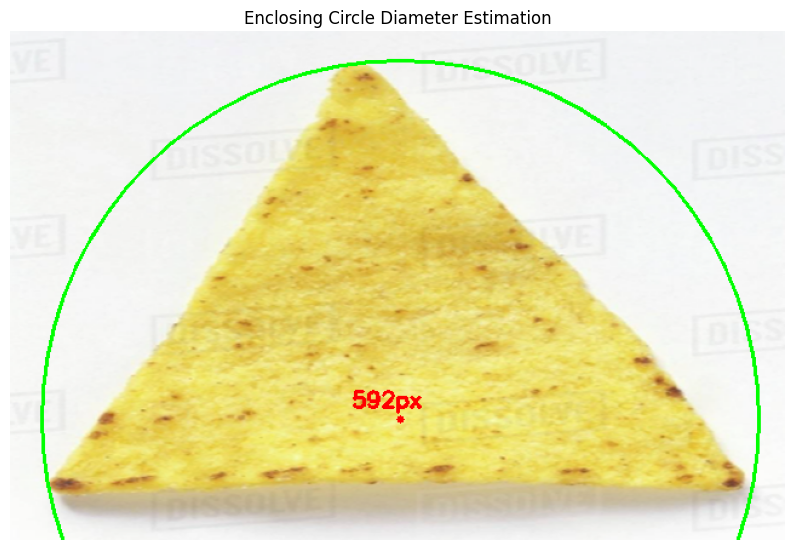

In [34]:
# minimun enclosing circle
circle_output = image_rgb.copy()

for cnt in contours:

    area = cv2.contourArea(cnt)

    if area > 1000:

        (x, y), radius = cv2.minEnclosingCircle(cnt)

        center = (int(x), int(y))
        radius = int(radius)
        diameter_pixels = radius * 2

        cv2.circle(
            circle_output,
            center,
            radius,
            (0,255,0),
            2
        )

        # Draw center point
        cv2.circle(
            circle_output,
            center,
            3,
            (255,0,0),
            -1
        )

        cv2.putText(
            circle_output,
            f"{diameter_pixels}px",
            (center[0]-40, center[1]-10),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.6,
            (255,0,0),
            2
        )

        print(f"Estimated Diameter: {diameter_pixels}px")

plt.figure(figsize=(10,10))
plt.imshow(circle_output)
plt.title("Enclosing Circle Diameter Estimation")
plt.axis("off")

In [36]:
mm_per_pixel = 0.1 # Placeholder: You may need to adjust this value based on your calibration
diameter_mm = diameter_pixels * mm_per_pixel

print(
    f"Diameter: {diameter_pixels}px | "
    f"Estimated: {diameter_mm:.2f} mm"
)

Diameter: 592px | Estimated: 59.20 mm


In [37]:
# 2D bounding
x, y, w, h = cv2.boundingRect(cnt)    # rectangular appproach

In [38]:
approx = cv2.approxPolyDP(cnt, 0.01 * cv2.arcLength(cnt, True), True)   # polygon approximation

Width: 582px | Height: 382px


(np.float64(-0.5), np.float64(639.5), np.float64(419.5), np.float64(-0.5))

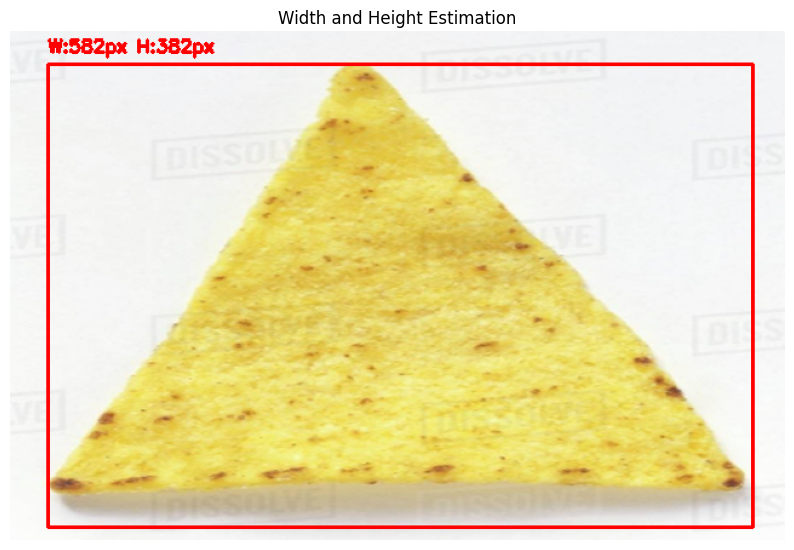

In [39]:
output_boxes = image_rgb.copy()

for cnt in contours:

    area = cv2.contourArea(cnt)

    if area > 1000:

        x, y, w, h = cv2.boundingRect(cnt)

        cv2.rectangle(
            output_boxes,
            (x, y),
            (x + w, y + h),
            (255, 0, 0),
            2
        )

        cv2.putText(
            output_boxes,
            f"W:{w}px H:{h}px",
            (x, y - 10),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.5,
            (255,0,0),
            2
        )

        print(f"Width: {w}px | Height: {h}px")

plt.figure(figsize=(10,10))
plt.imshow(output_boxes)
plt.title("Width and Height Estimation")
plt.axis("off")

Width: 582px | Height: 382px | Area: 119609.0


(np.float64(-0.5), np.float64(639.5), np.float64(419.5), np.float64(-0.5))

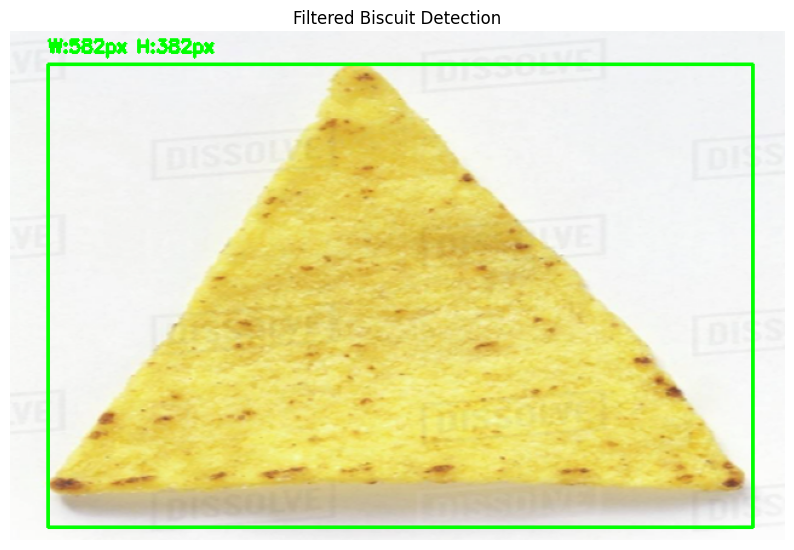

In [40]:
filtered_output = image_rgb.copy()

for cnt in contours:

    area = cv2.contourArea(cnt)
    if area > 3000:

        x, y, w, h = cv2.boundingRect(cnt)
        aspect_ratio = w / h

        # Optional filtering
        if 0.5 < aspect_ratio < 2.0:

            cv2.rectangle(
                filtered_output,
                (x, y),
                (x + w, y + h),
                (0,255,0),
                2
            )

            cv2.putText(
                filtered_output,
                f"W:{w}px H:{h}px",
                (x, y - 10),
                cv2.FONT_HERSHEY_SIMPLEX,
                0.5,
                (0,255,0),
                2
            )

            print(
                f"Width: {w}px | "
                f"Height: {h}px | "
                f"Area: {area}"
            )

plt.figure(figsize=(10,10))
plt.imshow(filtered_output)
plt.title("Filtered Biscuit Detection")
plt.axis("off")